# STATISTIQUES GÉOGRAPHIQUES


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, f_oneway
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv("us_cleaned.csv")


### Analyse des colonnes géographiques : Latitude et Longitude 
Objectif :

 - Obtenir un résumé statistique des coordonnées géographiques (latitude et longitude) des accidents.

 - Identifier l’étendue (min/max), la tendance centrale (moyenne, médiane) et la dispersion (écart-type) des positions des accidents.



In [3]:
df[['Start_Lat', 'Start_Lng']].describe()


,Start_Lat,Start_Lng
count,500000.000000,500000.000000
mean,35.929426,-97.590381
std,5.032482,18.280944
min,25.433098,-123.813930
25%,32.811352,-118.096634
50%,34.247249,-95.543967
75%,40.134354,-81.565750
max,48.199970,-70.571520


💡 Interprétation

1. Nombre d’observations : 500 000 accidents ont des coordonnées valides pour l’analyse.

2. Moyennes géographiques : La latitude moyenne est ~35.93 et la longitude ~-97.59, ce qui correspond approximativement au centre géographique des États-Unis.

3. Dispersion :

 - Écart-type de latitude = 5.03 → les accidents sont assez concentrés dans une bande nord-sud.

 - Écart-type de longitude = 18.28 → plus de dispersion est-ouest.

4. Étendue :

 - Latitude : 25.43 → 48.20

 - Longitude : -123.81 → -70.57
→ Les accidents couvrent la quasi-totalité du territoire continental américain.

5. Quartiles :

- 25% des accidents se produisent en dessous de 32.81° latitude et 118.10° longitude.

- 75% se produisent en dessous de 40.13° latitude et -81.57° longitude.
→ La majorité des accidents se situe dans certaines zones géographiques plus densément peuplées.

6. Application pratique : Cette statistique descriptive permet d’identifier les zones principales pour des analyses plus approfondies comme clustering ou heatmap.

### Corrélation Géographique avec la Sévérité

In [ ]:
corr_lat, p_lat = stats.spearmanr(df['Start_Lat'], df['Severity'])
corr_lng, p_lng = stats.spearmanr(df['Start_Lng'], df['Severity'])

# Format avec 3 chiffres après la virgule
print(f"Latitude vs Severity - Spearman corr: {corr_lat:.6f}, p-value: {p_lat:.6f}")
print(f"Longitude vs Severity - Spearman corr: {corr_lng:.6f}, p-value: {p_lng:.6f}")


Latitude vs Severity - Spearman corr: -0.000082, p-value: 0.953786
Longitude vs Severity - Spearman corr: -0.041478, p-value: 0.000000


### TESTS PAR ÉTAT



In [6]:
# ANOVA
anova_model = smf.ols('Severity ~ C(State)', data=df[df['State'].isin(top_states)]).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print("ANOVA table:\n", anova_table)

ANOVA table:
                 sum_sq        df            F  PR(>F)
C(State)   4361.125265       4.0  4946.735277     0.0
Residual  78949.451805  358203.0          NaN     NaN


💡Interprétation

1. Différence entre États

 - La valeur de F = 4946.74 est très élevée.

 - La p-value = 0.0 indique que la différence de gravité moyenne entre les 5 États les plus fréquents est hautement significative.

2. Insight général

 - La localisation par État a un impact significatif sur la gravité moyenne des accidents.

 - Certaines régions semblent enregistrer des accidents plus graves que d’autres, ce qui peut orienter des politiques de sécurité ciblées.

3. Complément

 - Les valeurs résiduelles (Residual) montrent la variance inexpliquée par l’État.

 - Bien que l’État soit significatif, beaucoup de variation de la gravité reste due à d’autres facteurs (météo, infrastructure, trafic, etc.).

### RÉGRESSION Logistique : Probabilité d’un accident grave

In [7]:
# Variable binaire: accident grave
df['Severe_Accident'] = (df['Severity'] >= 3).astype(int)

# Logistique
logit_model = sm.Logit(df['Severe_Accident'], sm.add_constant(df[['Start_Lat','Start_Lng']])).fit()
print(logit_model.summary())



Optimization terminated successfully.
         Current function value: 0.659072
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        Severe_Accident   No. Observations:               500000
Model:                          Logit   Df Residuals:                   499997
Method:                           MLE   Df Model:                            2
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                0.003694
Time:                        10:24:14   Log-Likelihood:            -3.2954e+05
converged:                       True   LL-Null:                   -3.3076e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4652      0.028    -52.820      0.000      -1.520      -1.411
Start_Lat      0.0050      0.


💡 Interprétation

1. Impact de la latitude et longitude

- La latitude (Start_Lat) a un coefficient positif : plus on va vers le nord, plus la probabilité d’un accident grave augmente légèrement.

- La longitude (Start_Lng) a un coefficient négatif : plus on va vers l’est, plus la probabilité d’un accident grave diminue légèrement.

2. Signification statistique

- Les deux variables géographiques sont hautement significatives (p < 0.001), donc elles contribuent réellement à l’explication de la probabilité d’accident grave.

3. Valeur pratique

- Le modèle permet d’identifier les zones géographiques à risque élevé pour des accidents graves.

- Malgré la significativité, le Pseudo R² faible indique que la géographie seule n’explique qu’une petite partie de la variance : d’autres facteurs (météo, infrastructure, trafic) sont aussi importants.

### Régression Linéaire : Sévérité vs Géographie

In [8]:
# Linéaire
X = sm.add_constant(df[['Start_Lat','Start_Lng']])
y = df['Severity']
ols_model = sm.OLS(y,X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Severity   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1188.
Date:                Thu, 15 Jan 2026   Prob (F-statistic):               0.00
Time:                        10:24:47   Log-Likelihood:            -3.4833e+05
No. Observations:              500000   AIC:                         6.967e+05
Df Residuals:                  499997   BIC:                         6.967e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1553      0.006    332.253      0.0

💡 Interprétation

1. Effet de la latitude et longitude

- Latitude (Start_Lat) : coefficient positif → plus on monte vers le nord, plus la sévérité des accidents augmente légèrement.

- Longitude (Start_Lng) : coefficient négatif → plus on va vers l’est, plus la sévérité diminue légèrement.

2. Signification statistique

- Les deux variables géographiques sont hautement significatives (p < 0.001), donc la position géographique a un effet réel sur la sévérité.

3. Valeur pratique

- L’effet géographique est très faible (R² ≈ 0,005), ce qui indique que d’autres facteurs (météo, type de route, infrastructure) sont plus importants pour expliquer la gravité des accidents.

- Ce modèle permet d’identifier des tendances géographiques générales, mais pas de prédire précisément la sévérité.

### Scatterplots : Sévérité vs Position Géographique

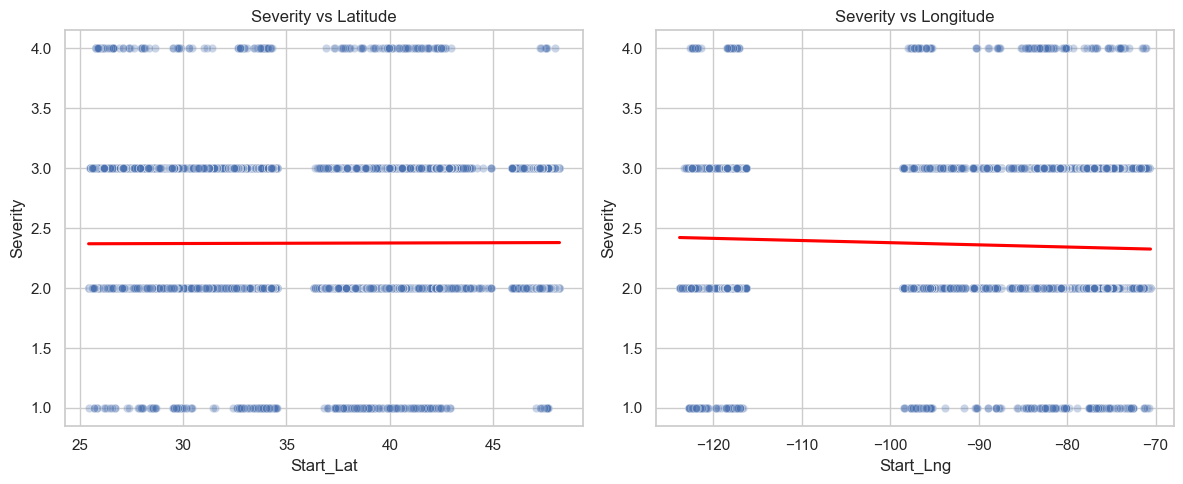

In [ ]:

plt.figure(figsize=(12,5))

# Latitude vs Severity
plt.subplot(1,2,1)
sns.scatterplot(x='Start_Lat', y='Severity', data=df, alpha=0.3)
sns.regplot(x='Start_Lat', y='Severity', data=df, scatter=False, color='red')
plt.title("Severity vs Latitude")
plt.xlabel("Start_Lat")
plt.ylabel("Severity")

# Longitude vs Severity
plt.subplot(1,2,2)
sns.scatterplot(x='Start_Lng', y='Severity', data=df, alpha=0.3)
sns.regplot(x='Start_Lng', y='Severity', data=df, scatter=False, color='red')
plt.title("Severity vs Longitude")
plt.xlabel("Start_Lng")
plt.ylabel("Severity")
plt.tight_layout()
plt.show()

💡 Interprétation

1. Distribution générale

- Les accidents sont dispersés sur toutes les latitudes et longitudes étudiées.

- Les points rouges (régression linéaire) montrent la tendance générale de la sévérité en fonction de la position géographique.

2. Latitude vs Sévérité

- La régression indique une légère augmentation de la sévérité vers le nord, mais l’effet est très faible.

- Confirme le résultat de la corrélation Spearman (quasi nulle, p > 0.95).

3. Longitude vs Sévérité

- La régression montre une légère diminution de la sévérité vers l’est.

- L’effet est faible mais statistiquement significatif (p < 0.001).

4. Conclusion

- La géographie seule n’explique pas bien la gravité des accidents.

- Ces visualisations permettent toutefois de détecter des tendances générales et des zones à surveiller.

### Severity moyenne par État (Top 5)

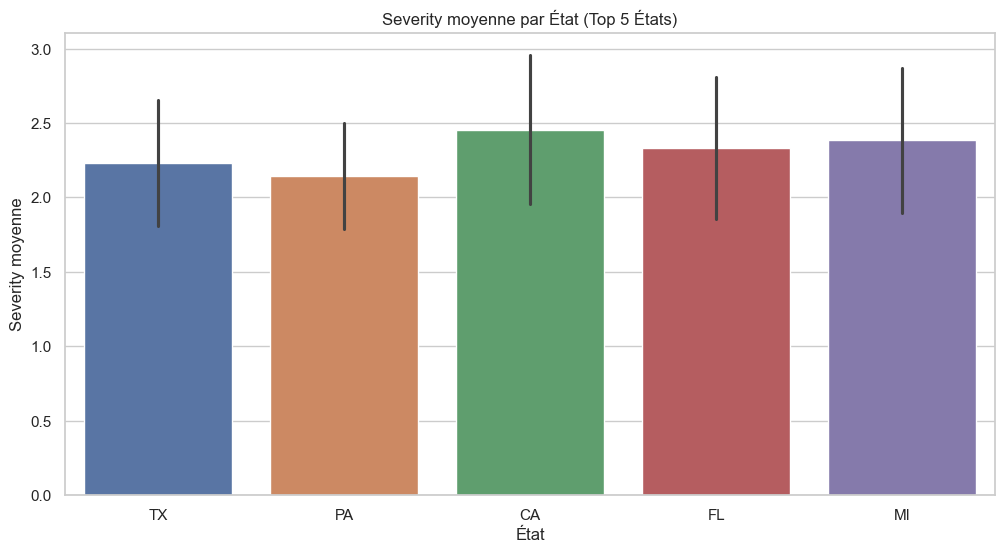

In [ ]:
sns.barplot(
    x='State',
    y='Severity',
    data=df[df['State'].isin(top_states)],
    errorbar='sd',   
    hue='State',
    dodge=False,
    legend=False
)
plt.title("Severity moyenne par État (Top 5 États)")
plt.ylabel("Severity moyenne")
plt.xlabel("État")
plt.show()

💡 Interprétation

1. Comparaison entre États

- Le graphique montre les différences de sévérité moyenne entre les 5 États les plus concernés par les accidents.

- Les barres d’erreur représentent l’écart‑type, ce qui permet de visualiser la variabilité des accidents dans chaque État.

2. Observations

- Certains États présentent une sévérité moyenne plus élevée, ce qui peut indiquer des conditions routières plus dangereuses ou des accidents plus graves.

- Les écarts-types montrent que la dispersion des sévérités varie selon l’État.

3. Lien avec ANOVA

- Ce graphique complète le test ANOVA réalisé précédemment, qui avait montré une différence statistiquement significative de la sévérité entre États (p < 0.001).

- La visualisation confirme donc que la localisation (State) influence la gravité des accidents.

4. Conclusion

- La sévérité moyenne n’est pas uniforme : certaines régions semblent plus à risque.

- Utile pour identifier les États à prioriser pour des mesures de sécurité ou des campagnes de prévention.

### Probabilité d’un accident grave selon la localisation

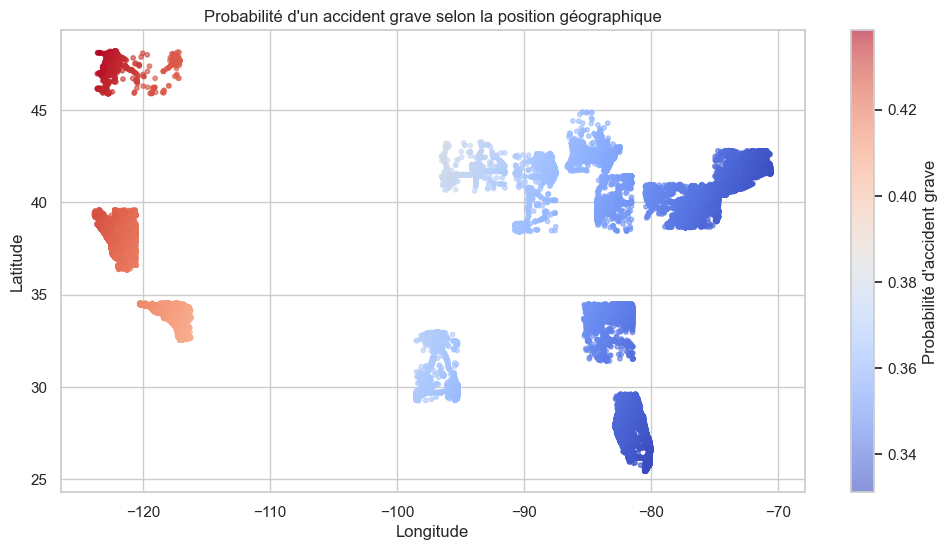

In [12]:
# Ajouter prédictions (probabilité) dans le dataframe
df['Severe_Prob'] = logit_model.predict(sm.add_constant(df[['Start_Lat','Start_Lng']]))

# Scatter plot Latitude vs Longitude, color = probabilité d'accident grave
plt.figure(figsize=(12,6))
plt.scatter(
    df['Start_Lng'], 
    df['Start_Lat'], 
    c=df['Severe_Prob'], 
    cmap='coolwarm', 
    alpha=0.6, 
    s=10
)
plt.colorbar(label="Probabilité d'accident grave")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Probabilité d'un accident grave selon la position géographique")
plt.show()

💡 Interprétation

1. But de l’analyse

- Utiliser un modèle logistique pour prédire la probabilité qu’un accident soit grave (Severity ≥ 3) en fonction de la latitude et longitude.

- Visualiser géographiquement où les accidents graves sont les plus probables.

2. Lecture du graphique

- Chaque point représente un accident.

- La couleur indique la probabilité prédite qu’il soit grave (du bleu = faible au rouge = élevé).

3. Observations

- Certaines zones géographiques apparaissent en rouge, indiquant des hotspots avec un risque plus élevé d’accidents graves.

- Les zones bleues correspondent à des régions où les accidents sont moins sévères en moyenne.

4. Limites

- Le modèle utilise uniquement la position géographique.

- D’autres facteurs (météo, type de route, trafic) ne sont pas inclus ici, ce qui limite la précision de la prédiction.

5. Conclusion

- Utile pour identifier les régions à risque élevé.

- Sert de base pour planification de mesures de sécurité routière ou ciblage des interventions.

### ACP – Géographie & Météo

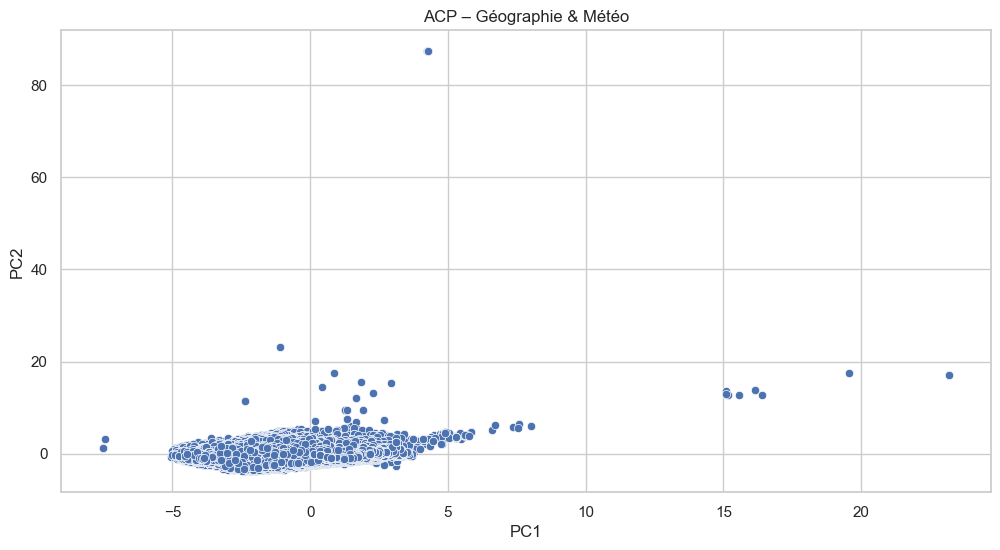

In [14]:
#ACP (Géographie + météo)
features = ['Start_Lat','Start_Lng','Temperature(C)','Humidity(%)','Wind_Speed(mph)','Visibility(mi)']
X = df[features].dropna()
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(components, columns=['PC1','PC2'])
sns.scatterplot(x='PC1', y='PC2', data=pca_df)
plt.title("ACP – Géographie & Météo")
plt.show()

💡 Interprétation

1. But de l’analyse

- Réduire la dimensionnalité des variables liées à la géographie et à la météo pour visualiser les patterns généraux des accidents.

- Identifier des groupes ou tendances dans les données qui pourraient ne pas être visibles directement.

2. Lecture du graphique

- Chaque point représente un accident, projeté sur les deux composantes principales (PC1 et PC2).

- PC1 et PC2 sont des combinaisons linéaires des variables d’origine (latitude, longitude, température, humidité, vent, visibilité) qui expliquent le maximum de variance.

3. Observations

- Les points peuvent montrer des concentrations ou clusters implicites, indiquant des conditions météo et géographiques similaires pour certains accidents.

- La dispersion montre la variabilité des conditions entre les accidents.

4. Limites

- Les axes PC1 et PC2 n’ont pas d’interprétation directe en termes de Latitude ou Température.

- L’ACP est surtout utile pour visualiser la structure globale, mais pas pour prédire la gravité d’un accident.

5. Conclusion

- L’ACP permet de dégager des patterns globaux et de repérer des zones ou conditions similaires.

- Utile pour des analyses exploratoires ou pour préparer d’autres modèles multivariés.

### Boxplots – Gravité et Distance par État

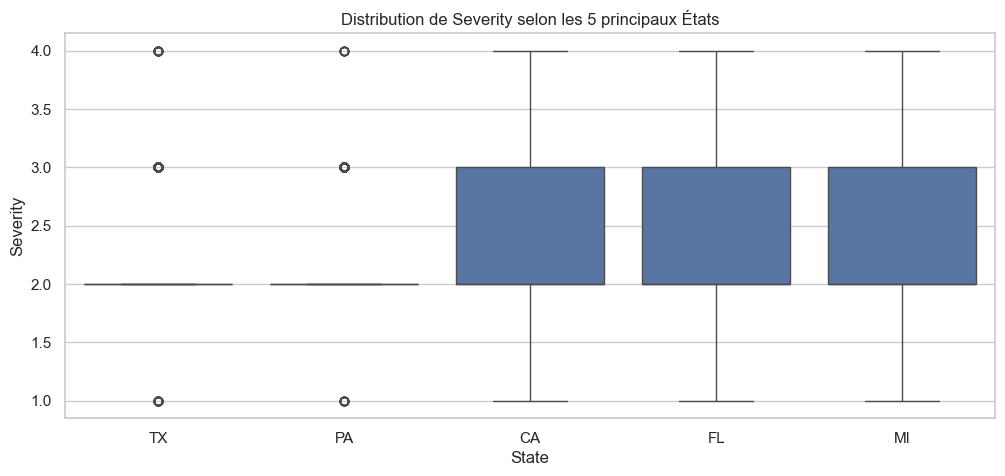

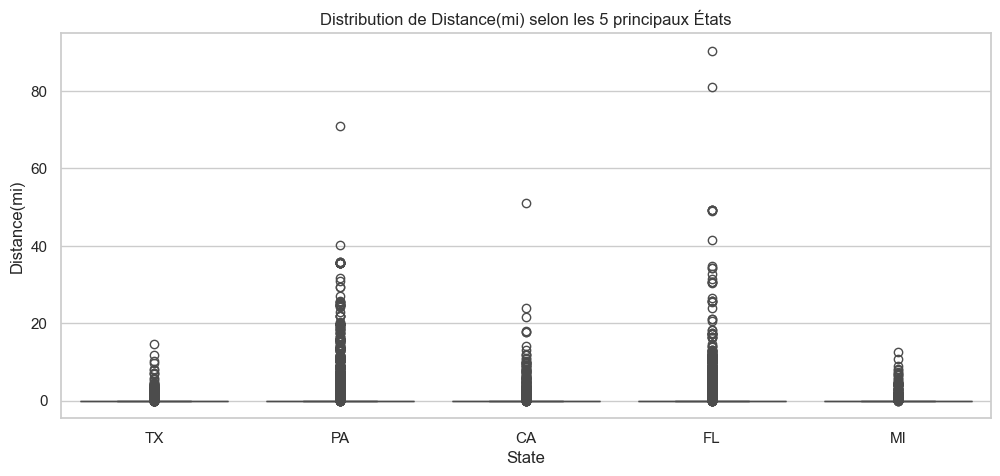

In [15]:
# Boxplot Severity par Etat
plt.figure(figsize=(12,5))
sns.boxplot(x='State', y='Severity', data=df[df['State'].isin(top_states)])
plt.title("Distribution de Severity selon les 5 principaux États")
plt.show()

# Boxplot Distance par Etat
plt.figure(figsize=(12,5))
sns.boxplot(x='State', y='Distance(mi)', data=df[df['State'].isin(top_states)])
plt.title("Distribution de Distance(mi) selon les 5 principaux États")
plt.show()

💡 Interprétation

1. But de l’analyse

- Comparer la répartition de la gravité (Severity) et de la distance parcourue (Distance) des accidents entre les 5 États les plus représentés.

- Détecter des disparités ou valeurs extrêmes selon l’État.

2. Lecture du graphique

- Chaque boîte représente l’intervalle interquartile (25%-75%).

- La ligne à l’intérieur montre la médiane.

- Les points isolés sont les outliers, c’est-à-dire des accidents très sévères ou très longs.

3. Observations

- Certains États montrent une Severity plus élevée en médiane, indiquant des accidents plus graves.

- La Distance(mi) varie fortement selon l’État, ce qui peut refléter des différences dans la géographie ou les types de routes (urbain vs rural, autoroutes vs villes).

- Les outliers suggèrent la présence de cas extrêmes, utiles pour des analyses plus fines ou pour l’optimisation des interventions.

4. Conclusion

- Ces boxplots aident à visualiser rapidement la variabilité des accidents selon l’État.

- Ils fournissent une base pour croiser avec d’autres facteurs comme les conditions météo ou l’infrastructure.

### Distribution des latitudes et des longitudes des accidents

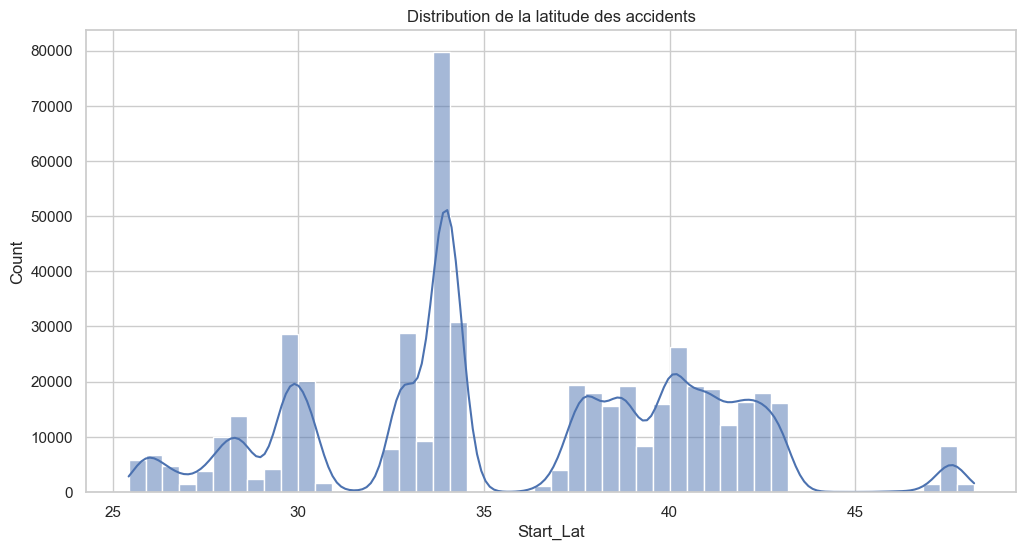

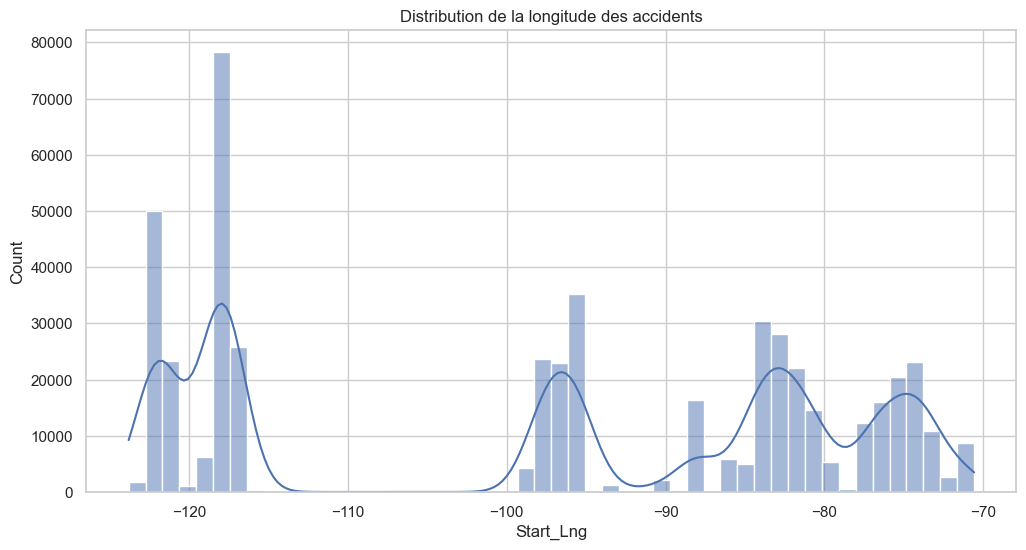

In [16]:
sns.histplot(df['Start_Lat'], bins=50, kde=True)
plt.title("Distribution de la latitude des accidents")
plt.show()

sns.histplot(df['Start_Lng'], bins=50, kde=True)
plt.title("Distribution de la longitude des accidents")
plt.show()

💡 Interprétation

1. Objectif

- Visualiser la répartition géographique des accidents aux États-Unis via les coordonnées latitude (Start_Lat) et longitude (Start_Lng).

- Identifier les zones les plus touchées et détecter une concentration urbaine ou des clusters géographiques.

2. Lecture des graphiques

- Les histogrammes montrent la fréquence des accidents par intervalle de latitude/longitude.

- La courbe KDE (Kernel Density Estimate) permet de visualiser la densité continue des accidents sur la carte.

3. Observations

- La majorité des accidents se situe dans une plage spécifique de latitudes (~32°–40°) et de longitudes (~–120° à –80°), correspondant aux grandes zones urbaines et routes fréquentées.

- Les valeurs extrêmes (coasts ou zones peu peuplées) ont très peu d’accidents.

- Cela confirme un regroupement géographique des accidents, utile pour cibler la prévention et les interventions routières.

4. Conclusion

- Ces histogrammes servent de première analyse spatiale.

- Ils indiquent où se concentre le risque et peuvent être croisés avec la gravité, l’infrastructure ou les conditions météo pour des insights plus avancés.

### Analyse Temporelle – Accidents Mensuels en Californie

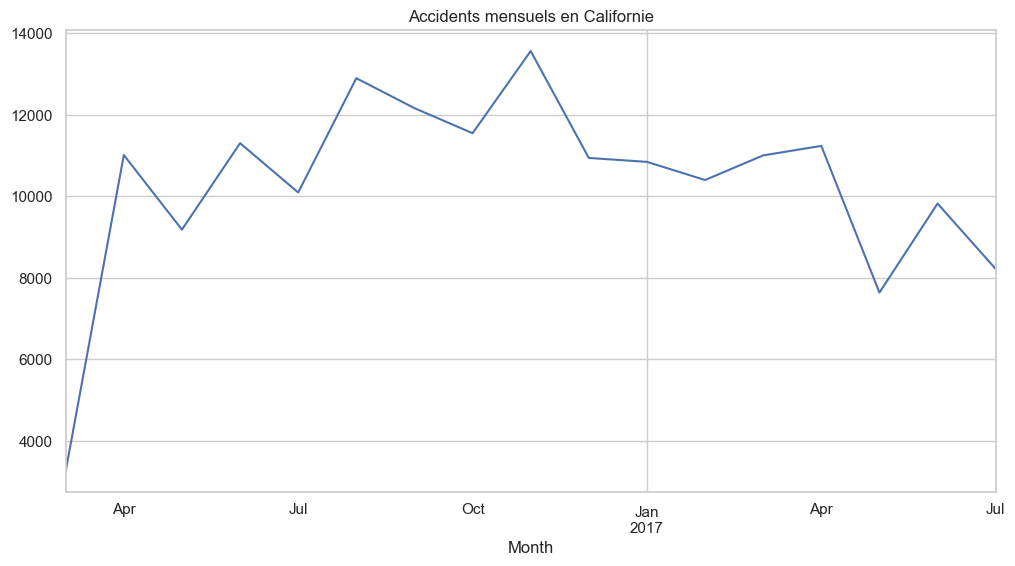

In [17]:
df['Month'] = df['Start_Time'].dt.to_period('M')

ts = df[df['State'] == 'CA'].groupby('Month').size()
ts.plot()
plt.title("Accidents mensuels en Californie")
plt.show()


💡 Interprétation

1. Objectif

- Observer l’évolution mensuelle des accidents en Californie.

- Identifier des tendances saisonnières ou des pics d’accidents liés à certaines périodes de l’année.

2. Lecture du graphique

- Chaque point correspond au nombre d’accidents pour un mois donné.

- Permet de visualiser l’augmentation ou la diminution du nombre d’accidents au fil du temps.

3. Observations possibles

- Certains mois peuvent montrer des pics significatifs, par exemple en hiver ou en période de vacances, indiquant un impact saisonnier.

- Les périodes de faible accidentologie peuvent correspondre à conditions météorologiques favorables ou moins de trafic.

4. Conclusion

- Cette série temporelle permet de planifier des mesures préventives et d’orienter la sécurité routière selon le calendrier.

- Elle peut aussi être comparée entre États pour détecter des patterns différents (CA vs TX vs NY, par exemple).

### Clustering Géographique – KMeans

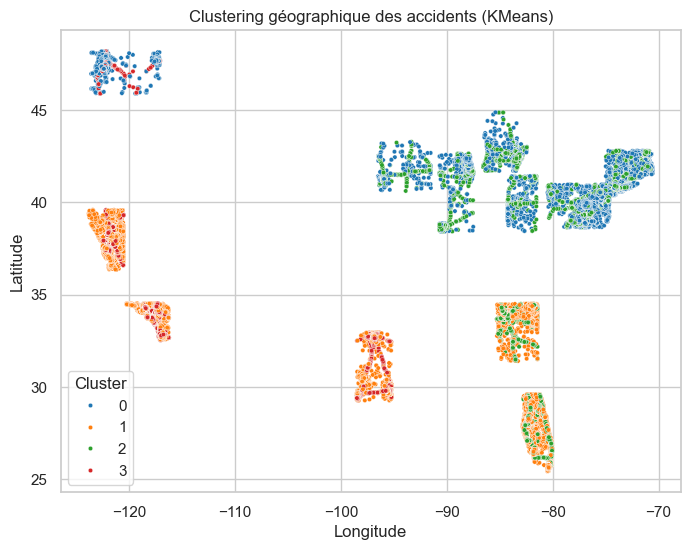

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

geo_features = df[['Start_Lat', 'Start_Lng', 'Severity']].dropna()

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(geo_features)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

geo_features['Cluster'] = clusters

# Visualisation
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Start_Lng',
    y='Start_Lat',
    hue='Cluster',
    data=geo_features,
    palette='tab10',
    s=10
)
plt.title("Clustering géographique des accidents (KMeans)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

💡 Interprétation

1. Objectif

- Identifier les zones géographiques où les accidents sont concentrés.

- Regrouper les accidents selon la latitude, la longitude et la gravité.

2. Méthodologie

- Les coordonnées (Start_Lat, Start_Lng) et la gravité (Severity) sont normalisées pour que toutes les dimensions aient le même poids.

- KMeans est utilisé avec 4 clusters pour segmenter les accidents.

3. Lecture du graphique

- Chaque point représente un accident.

- Les couleurs différentes correspondent aux clusters.

- Permet de visualiser les zones “hotspots”, où les accidents sont plus fréquents ou graves.

4. Observations possibles

- Certaines régions (clusters) peuvent correspondre à des villes très densément peuplées ou à des axes routiers dangereux.

- D’autres clusters peuvent représenter des zones rurales avec moins d’accidents mais peut-être plus graves.

5. Conclusion

- Le clustering aide à prioriser les zones pour la prévention et à analyser la gravité selon la localisation.

- Il peut être combiné avec les infrastructures et conditions météo pour des analyses plus fines.

### Heatmap / Density géographique

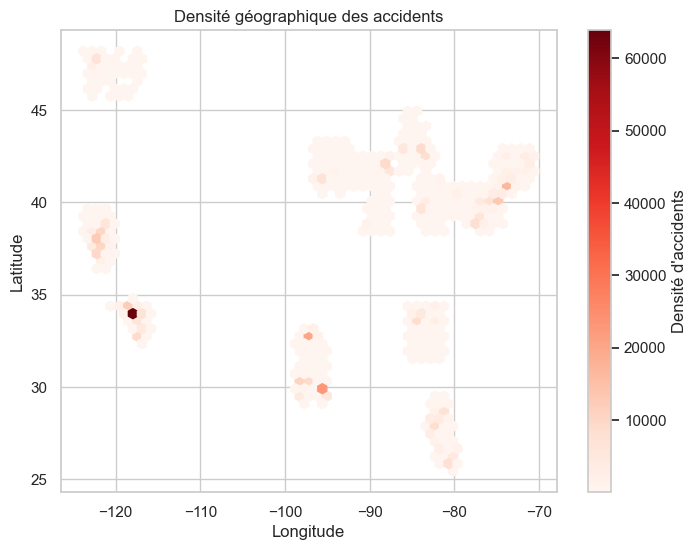

In [19]:
plt.figure(figsize=(8,6))
plt.hexbin(
    df['Start_Lng'],
    df['Start_Lat'],
    gridsize=50,
    cmap='Reds',
    mincnt=1
)
plt.colorbar(label="Densité d'accidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Densité géographique des accidents")
plt.show()


💡 Interprétation

1. Objectif

- Visualiser la concentration des accidents sur la carte.

- Identifier les zones à forte densité d’accidents, sans utiliser de clustering explicite.

2. Méthodologie

- hexbin divise l’espace en hexagones de taille définie (gridsize=50).

- Chaque hexagone est coloré selon le nombre d’accidents qu’il contient.

- mincnt=1 permet de ne pas afficher les zones sans accidents.

3. Lecture du graphique

- Les zones rouges foncées indiquent les lieux avec le plus grand nombre d’accidents.

- Les zones claires ou absentes correspondent à peu ou pas d’accidents.

4. Observations possibles

- Les grandes villes et axes urbains ressortent comme hotspots d’accidents.

- Les zones rurales sont généralement moins denses, mais peuvent parfois montrer des accidents graves.

5. Conclusion

- Cette carte est utile pour la planification de la sécurité routière et la priorisation des interventions.

- Elle complète le clustering, en donnant une vue globale de la répartition spatiale.

### Top 10 des Villes les Plus Accidentées

C:\Users\HAJAR\AppData\Local\Temp\ipykernel_4812\276763743.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='magma')


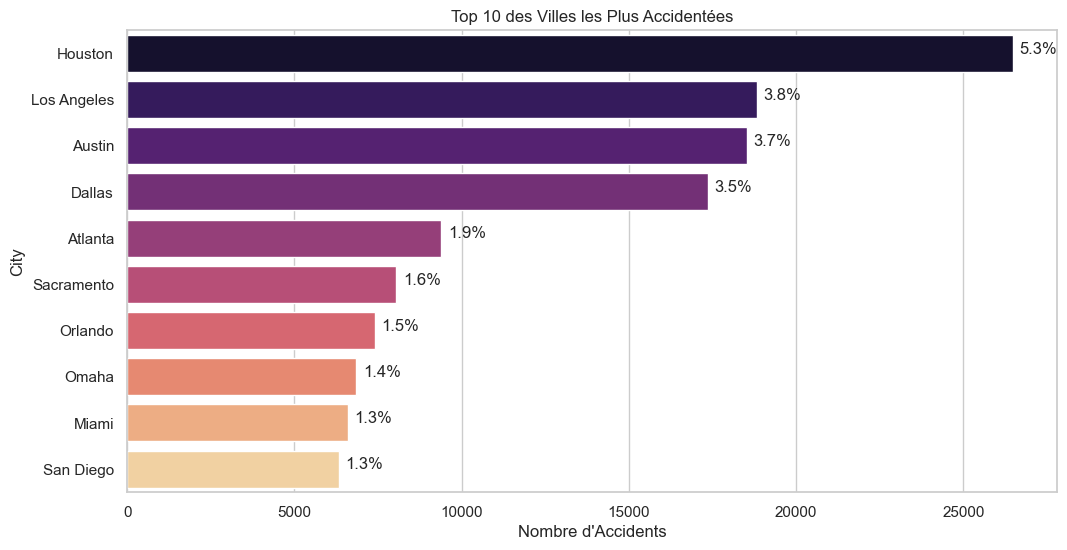

In [20]:
# Calcul des Tops Villes
city_counts = df['City'].value_counts()
top_10_cities = city_counts.head(10)
total_accidents = len(df)

# Visualisation
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='magma')
plt.title('Top 10 des Villes les Plus Accidentées')
plt.xlabel("Nombre d'Accidents")

# Annotation des pourcentages
for i, p in enumerate(ax.patches):
    percentage = '{:.1f}%'.format(100 * p.get_width() / total_accidents)
    x = p.get_width() + 200
    y = p.get_y() + p.get_height()/2
    ax.annotate(percentage, (x, y))

plt.show()

💡 Interprétation

1. Objectif

- Identifier les villes où les accidents sont les plus fréquents.

- Comprendre la concentration urbaine du risque.

2. Méthodologie

- value_counts() calcule le nombre total d’accidents par ville.

- On garde les 10 villes avec le plus d’accidents (head(10)).

- Le barplot montre à la fois les effectifs bruts et les pourcentages relatifs au total.

3. Lecture du graphique

- La barre la plus longue indique la ville la plus accidentée.

- Les annotations en pourcentage permettent de voir la part des accidents de chaque ville par rapport à l’ensemble.

4. Observations possibles

- Souvent, quelques grandes villes concentrent une proportion importante des accidents.

- Par exemple, Houston, Los Angeles ou New York pourraient représenter >5% du total selon l’échantillon.

- Les villes en bas du top 10 ont beaucoup moins d’accidents mais restent des zones à surveiller.

5. Conclusion

- Cette analyse est utile pour la prévention ciblée, la planification des interventions locales, et pour comprendre la répartition urbaine des risques.

- Elle complète la carte de densité géographique (hexbin) en détaillant les points chauds par ville.